# Praktikum Machine Learning
## 📘 Pertemuan 2: Data Preprocessing dan EDA

Nama  : Endang Adiningsih  
NIM   : 105841117723 

### Tujuan
1. Membersihkan data (missing value dan duplikat).
2. Menangani outlier pada kolom numerik.
3. Melakukan scaling fitur numerik.
4. Melakukan Exploratory Data Analysis (EDA).
5. Menarik insight awal sebelum modeling.

## 1️⃣ Menampilkan Ukuran Data dan Tipe Kolom

Pada tugas pertama, dilakukan eksplorasi awal untuk mengetahui ukuran dataset dan tipe data setiap kolom.
Informasi ini penting untuk menentukan langkah preprocessing yang sesuai.

In [ ]:
# =========================================
# TUGAS 1 LOAD DATASET
# =========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset Titanic
df = sns.load_dataset("titanic")

print("=== TUGAS 1: INFORMASI AWAL DATASET ===")
print("Ukuran Data (Baris, Kolom):", df.shape)
print("\nTipe Data Tiap Kolom:")
print(df.dtypes)

=== TUGAS 1: INFORMASI AWAL DATASET ===
Ukuran Data (Baris, Kolom): (891, 15)

Tipe Data Tiap Kolom:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


##  2️⃣ Menangani Missing Value dan Duplikat

Berdasarkan observasi awal, terdapat missing value pada beberapa kolom seperti age, deck, dan embarked. 
Missing value pada age diisi median karena lebih stabil terhadap outlier. Embarked diisi modus karena kategorikal.
Kolom deck dihapus karena terlalu banyak kosong. Duplikat dihapus agar data tidak bias.

In [ ]:
# =========================================
# TUGAS 2 - MISSING VALUE & DUPLIKAT
# =========================================

print("=== TUGAS 2: Missing Value Sebelum ===")
print(df.isnull().sum())

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df = df.drop(columns=["deck"])
df = df.drop_duplicates()

print("\n=== TUGAS 2: Missing Value Setelah ===")
print(df.isnull().sum())
print("Ukuran Data Setelah Bersih:", df.shape)

=== TUGAS 2: Missing Value Sebelum ===
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

=== TUGAS 2: Missing Value Setelah ===
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64
Ukuran Data Setelah Bersih: (775, 14)


## Outlier Handling

Outlier ditangani menggunakan metode IQR dan dilakukan clipping agar distribusi lebih stabil.

In [ ]:
# =========================================
# TUGAS 3 OUTLIER HANDING
# =========================================
def handle_outlier_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    data[column] = data[column].clip(low, high)
    return data

df = handle_outlier_iqr(df, "age")
df = handle_outlier_iqr(df, "fare")

print("=== TUGAS 3: Deskripsi Setelah Outlier Handling ===")
print(df[["age", "fare"]].describe())

=== TUGAS 3: Deskripsi Setelah Outlier Handling ===
              age        fare
count  775.000000  775.000000
mean    29.363123   26.593137
std     13.211598   22.873099
min      0.420000    0.000000
25%     21.000000    8.050000
50%     28.000000   15.900000
75%     36.000000   34.197900
max     58.500000   73.419750


## Scaling
Scaling menggunakan StandardScaler agar fitur numerik memiliki mean 0 dan standar deviasi 1.

In [ ]:
# =========================================
# TUGAS 4 SCALING
# =========================================

scaler = StandardScaler()
df[["age", "fare"]] = scaler.fit_transform(df[["age", "fare"]])

print("=== TUGAS 4: Deskripsi Setelah Scaling ===")
print(df[["age", "fare"]].describe())

=== TUGAS 4: Deskripsi Setelah Scaling ===
                age          fare
count  7.750000e+02  7.750000e+02
mean  -4.584147e-18 -1.375244e-17
std    1.000646e+00  1.000646e+00
min   -2.192151e+00 -1.163389e+00
25%   -6.334225e-01 -8.112198e-01
50%   -1.032428e-01 -4.678003e-01
75%    5.026768e-01  3.326910e-01
max    2.206826e+00  2.048557e+00


## EDA
Tahap ini menampilkan lima visualisasi utama dalam satu figure untuk melihat distribusi data dan hubungan antar variabel.

=== TUGAS 5: EXPLORATORY DATA ANALYSIS ===


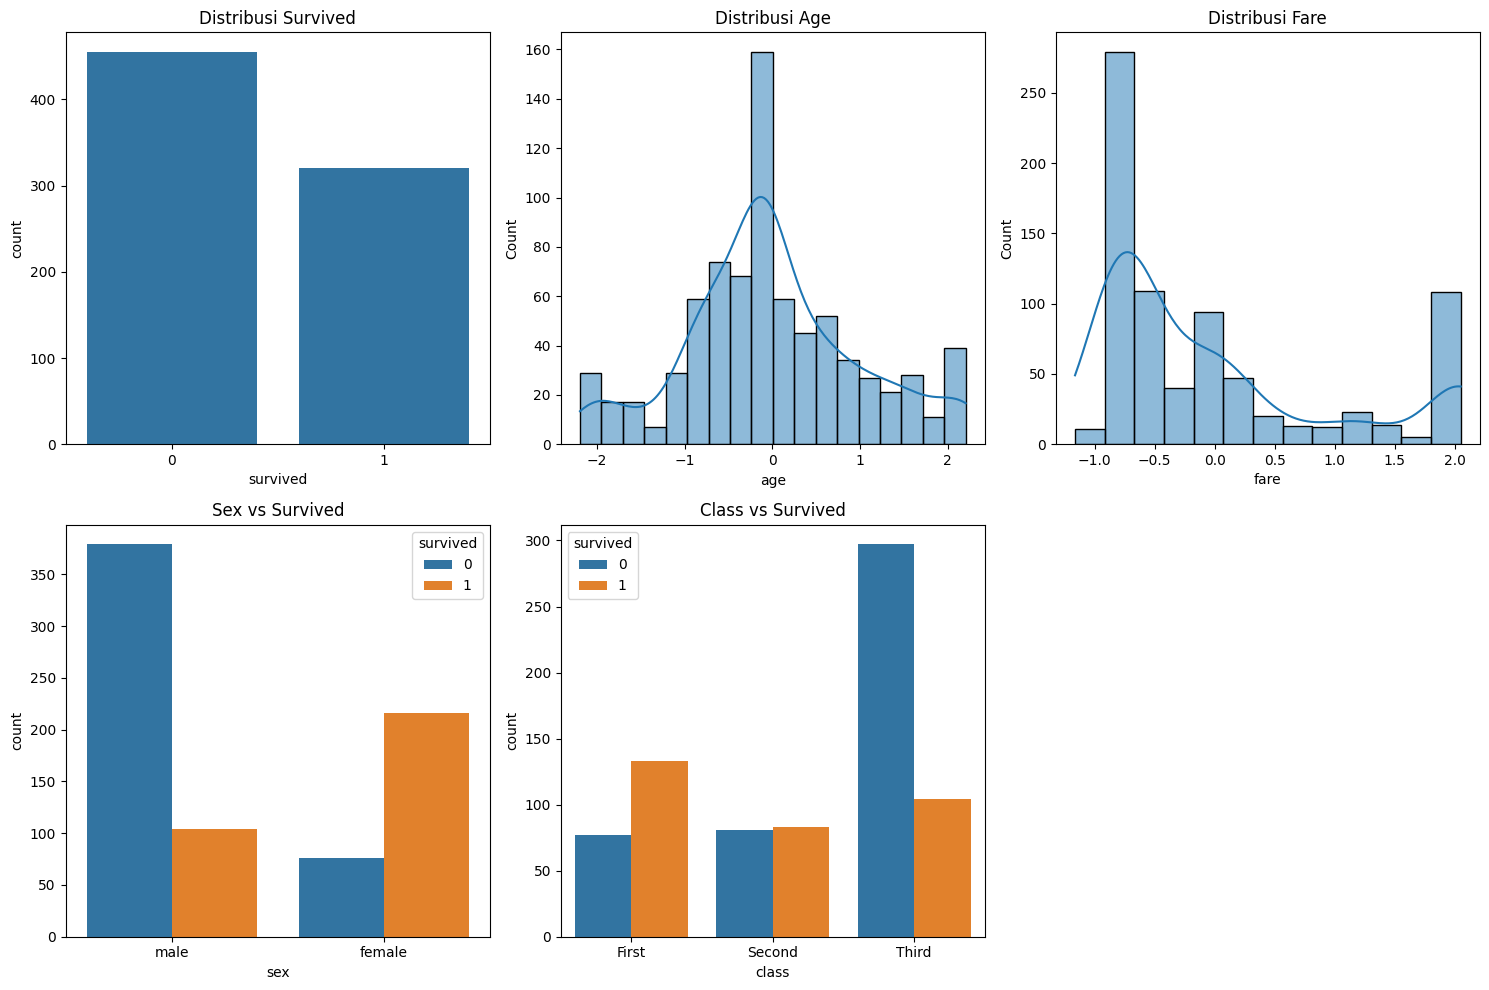


=== INSIGHT HASIL EDA ===
1. Tidak selamat: 455 (58.71%)
   Selamat: 320 (41.29%)
   Mayoritas penumpang tidak selamat.

2. Standar deviasi usia setelah scaling: 1.00
   Nilai mendekati 1 menunjukkan proses scaling berhasil.

3. Standar deviasi fare setelah scaling: 1.00
   Variasi fare telah dinormalisasi.

4. Tingkat keselamatan berdasarkan gender:
   - female: 73.97%
   - male: 21.53%
   Perempuan memiliki peluang selamat lebih tinggi.

5. Tingkat keselamatan berdasarkan kelas:
   - First: 63.33%
   - Second: 50.61%
   - Third: 25.94%
   Kelas First memiliki peluang selamat tertinggi.


In [ ]:
# ==============================
# TUGAS 5 - EDA + INSIGHT
# ==============================

print("=== TUGAS 5: EXPLORATORY DATA ANALYSIS ===")

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribusi Survived
sns.countplot(x="survived", data=df, ax=axes[0,0])
axes[0,0].set_title("Distribusi Survived")

# 2. Distribusi Age
sns.histplot(df["age"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Distribusi Age")

# 3. Distribusi Fare
sns.histplot(df["fare"], kde=True, ax=axes[0,2])
axes[0,2].set_title("Distribusi Fare")

# 4. Sex vs Survived
sns.countplot(x="sex", hue="survived", data=df, ax=axes[1,0])
axes[1,0].set_title("Sex vs Survived")

# 5. Class vs Survived
sns.countplot(x="class", hue="survived", data=df, ax=axes[1,1])
axes[1,1].set_title("Class vs Survived")

# Kosongkan subplot terakhir
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# INSIGHT
# ==============================

print("\n=== INSIGHT HASIL EDA ===")

# Insight 1 - Distribusi Survived
survival_counts = df["survived"].value_counts()
total = len(df)
print(f"1. Tidak selamat: {survival_counts[0]} ({survival_counts[0]/total:.2%})")
print(f"   Selamat: {survival_counts[1]} ({survival_counts[1]/total:.2%})")
print("   Mayoritas penumpang tidak selamat.\n")

# Insight 2 - Age (gunakan std karena sudah scaling)
print(f"2. Standar deviasi usia setelah scaling: {df['age'].std():.2f}")
print("   Nilai mendekati 1 menunjukkan proses scaling berhasil.\n")

# Insight 3 - Fare (gunakan std karena sudah scaling)
print(f"3. Standar deviasi fare setelah scaling: {df['fare'].std():.2f}")
print("   Variasi fare telah dinormalisasi.\n")

# Insight 4 - Survival berdasarkan gender
survival_by_sex = df.groupby("sex", observed=False)["survived"].mean()
print("4. Tingkat keselamatan berdasarkan gender:")
for sex, rate in survival_by_sex.items():
    print(f"   - {sex}: {rate:.2%}")
print("   Perempuan memiliki peluang selamat lebih tinggi.\n")

# Insight 5 - Survival berdasarkan kelas
survival_by_class = df.groupby("class", observed=False)["survived"].mean()
print("5. Tingkat keselamatan berdasarkan kelas:")
for cls, rate in survival_by_class.items():
    print(f"   - {cls}: {rate:.2%}")
print("   Kelas First memiliki peluang selamat tertinggi.")